In [2]:
# imports
import os
print("cwd:", os.getcwd())

import pickle
import numpy as np
import k3d
import matplotlib.pyplot as plt

import torch
import pytorch3d.io as io
from pytorch3d.transforms import axis_angle_to_matrix

from utils.point_cloud_utils import normalize_point_cloud
from utils.geodesic_utils import fix_geodesic_distance_for_disconnected_components

from utils import tab10_values as tab10
from utils import tab10_light_values as tab10_light

cwd: /home/gkobsik/Partial-Symmetry-Detection-for-3D-Geometry


In [41]:
shape_name = "faucet"

dir_path = f"data/precomputed/{shape_name}"
prefix = "clr_"  # SymCL results (precomputed.zip ships clr_* files)

def load_pickle(file_path):
    """Convinience function to quicker load of vars with pickle."""
    with open(file_path, "rb") as file:
        var = pickle.load(file)
    return var

# load .obj mesh file
print("Loading mesh data ...")
file_path = f"data/meshes/{shape_name}.obj"
shape_obj = io.load_obj(file_path, load_textures=False)
verts, faces = shape_obj[0], shape_obj[1][0]
verts = normalize_point_cloud(verts.type(torch.float32))
print("done.")

# load precomputed patch and distance data
print("Loading patch and distance data ...")
pcl = np.load(f"{dir_path}/pcl.npy")
print("done.")

# load precomputed region growing data
print("Loading region growing data ...")
clusters_components_idx = load_pickle(f"{dir_path}/{prefix}clusters_components_idx.pkl")
clusters_icp_distance = load_pickle(f"{dir_path}/{prefix}clusters_icp_distance.pkl")
region_growing_components_idx = load_pickle(f"{dir_path}/{prefix}region_growing_components_idx.pkl")
regions_packed_components_idx = load_pickle(f"{dir_path}/{prefix}regions_packed_components_idx.pkl")
regions_growing_max_icp_dists = load_pickle(f"{dir_path}/{prefix}regions_growing_max_icp_dists.pkl")
print("done.")

print("# of regions:", len(regions_packed_components_idx))

Loading mesh data ...
done.
Loading patch and distance data ...
done.
Loading region growing data ...
done.
# of regions: 3


In [42]:
# The precomputed shapes are Y-up with the front facing +Z; k3d is Z-up.
# Rotate -90 deg about X (row-vector convention: v @ R) so Y -> Z (up) and +Z -> -Y (front).
R_x = axis_angle_to_matrix(torch.tensor([-np.pi / 2, 0.0, 0.0]))
R_z = axis_angle_to_matrix(torch.tensor([0.0, 0.0, -np.pi / 3]))  # optional extra spin around the up axis

R = (R_x @ R_z).numpy()


In [43]:
IDX = 1
RG_IDX = 25

plot = k3d.plot(grid_visible=False, camera_fov=30)
plot += k3d.mesh(verts @ R, faces, color=0xFFFFFF)

for i, idx in enumerate(clusters_components_idx[IDX]):
      plot += k3d.points(pcl[idx] @ R, point_size=0.03, color=tab10[i % 10])

for i, idx in enumerate(region_growing_components_idx[IDX]):
    plot += k3d.points(pcl[np.concatenate(idx[:RG_IDX])] @ R, point_size=0.01, color=tab10_light[i % 10])

plot

/tmp/ipykernel_168424/2921947913.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plot += k3d.mesh(verts @ R, faces, color=0xFFFFFF)


Plot(antialias=3, axes=['x', 'y', 'z'], axes_helper=1.0, axes_helper_colors=[16711680, 65280, 255], background…

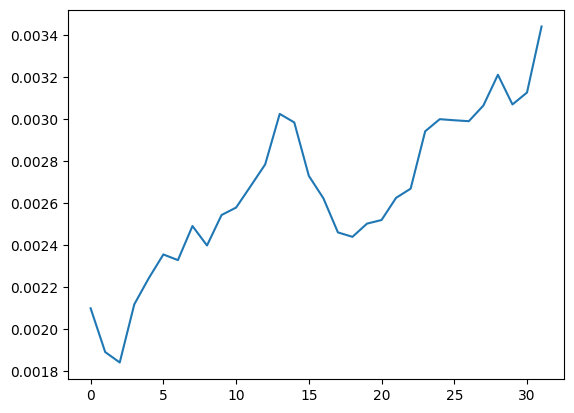

In [34]:
plt.plot(regions_growing_max_icp_dists[IDX])